# Dataset

In [ ]:
!pip install fpdf2 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 10.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import random

np.random.seed(42)
random.seed(42)

n = 200
cities = ["Delhi", "Mumbai", "Bangalore", "Chennai", "Hyderabad", "Kolkata", "Pune", "Jaipur"]
claim_types = ["Medical", "Vehicle", "Property", "Life", "Travel"]

data = {
    "Customer_ID":            [f"CUST{1000+i}" for i in range(n)],
    "Age":                    np.random.randint(22, 70, n).tolist(),
    "Claim_Amount":           np.random.randint(5000, 200000, n).tolist(),
    "Claim_Type":             [random.choice(claim_types) for _ in range(n)],
    "Location":               [random.choice(cities) for _ in range(n)],
    "Previous_Claims":        np.random.randint(0, 8, n).tolist(),
    "Policy_Duration_Years":  np.random.randint(1, 20, n).tolist(),
    "Annual_Premium":         np.random.randint(5000, 50000, n).tolist(),
    "Number_of_Dependents":   np.random.randint(0, 5, n).tolist(),
}

fraud = []
for i in range(n):
    score = 0
    if data["Claim_Amount"][i] > 120000:          score += 2
    if data["Previous_Claims"][i] > 4:            score += 2
    if data["Policy_Duration_Years"][i] < 2:      score += 1
    fraud.append("Yes" if score >= 3 else "No")

data["Fraud"] = fraud

df = pd.DataFrame(data)
df.to_csv("insurance_claims.csv", index=False)

print("Dataset created!")
print(f"Shape: {df.shape}")
print(f"\nFraud distribution:\n{df['Fraud'].value_counts()}")
print(f"\nFirst 5 rows:")
df.head()

Dataset created!
Shape: (200, 10)

Fraud distribution:
Fraud
No     158
Yes     42
Name: count, dtype: int64

First 5 rows:


,Customer_ID,Age,Claim_Amount,Claim_Type,Location,Previous_Claims,Policy_Duration_Years,Annual_Premium,Number_of_Dependents,Fraud
0,CUST1000,60,73840,Medical,Mumbai,0,3,18456,1,No
1,CUST1001,50,123451,Medical,Delhi,7,1,43765,2,Yes
2,CUST1002,36,190456,Property,Chennai,0,1,39816,4,Yes
3,CUST1003,64,56005,Vehicle,Mumbai,0,8,22100,3,No
4,CUST1004,29,182648,Vehicle,Delhi,2,10,26949,4,No


In [ ]:
from fpdf import FPDF

pdf = FPDF()
pdf.add_page()

pdf.set_fill_color(41, 98, 255)
pdf.set_text_color(255, 255, 255)
pdf.set_font("Arial", style='B', size=16)
pdf.cell(200, 12, txt="INSURANCE CLAIM FORM", ln=True, align='C', fill=True)
pdf.ln(8)

pdf.set_text_color(0, 0, 0)
fields = [
    ("Claim Number:",       "CLM-2024-00123"),
    ("Policy Number:",      "POL-789456"),
    ("Customer Name:",      "Harshita Dubey"),
    ("Date of Claim:",      "15-April-2024"),
    ("Claim Type:",         "Vehicle"),
    ("Claim Amount:",       "Rs. 75,000"),
    ("Location:",           "Delhi"),
    ("Previous Claims:",    "2"),
    ("Annual Premium:",     "Rs. 18,000"),
    ("Policy Duration:",    "3 Years"),
    ("No. of Dependents:",  "2"),
    ("Description:",        "Vehicle damaged in accident near Connaught Place, Delhi"),
]

for label, value in fields:
    pdf.set_font("Arial", style='B', size=12)
    pdf.cell(80, 10, txt=label)
    pdf.set_font("Arial", size=12)
    pdf.cell(110, 10, txt=value, ln=True)
    pdf.line(10, pdf.get_y(), 200, pdf.get_y())

pdf.ln(6)
pdf.set_font("Arial", style='I', size=10)
pdf.cell(200, 8, txt="This is a sample claim form generated for Azure Document Intelligence demonstration.", ln=True, align='C')

pdf.output("sample_claim_form.pdf")
print("PDF created: sample_claim_form.pdf")

PDF created: sample_claim_form.pdf


/tmp/ipykernel_6492/1994009181.py:8: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font("Arial", style='B', size=16)
/tmp/ipykernel_6492/1994009181.py:9: DeprecationWarning: The parameter "txt" has been renamed to "text" in 2.7.6
  pdf.cell(200, 12, txt="INSURANCE CLAIM FORM", ln=True, align='C', fill=True)
/tmp/ipykernel_6492/1994009181.py:9: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(200, 12, txt="INSURANCE CLAIM FORM", ln=True, align='C', fill=True)
/tmp/ipykernel_6492/1994009181.py:29: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font("Arial", style='B', size=12)
/tmp/ipykernel_6492/1994009181.py:30: DeprecationWarning: The parameter "txt" has been renamed to "text" in 2.7.6
  pdf.cell(80, 10, txt=label)
/tmp

In [ ]:
from google.colab import files

files.download("insurance_claims.csv")
files.download("sample_claim_form.pdf")

print("Both files downloaded!")
print("Next steps:")
print("1. Upload insurance_claims.csv → to Azure ML & Azure Search (later parts)")
print("2. Upload sample_claim_form.pdf → to GitHub (for public URL in Part 2)")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Both files downloaded!
Next steps:
1. Upload insurance_claims.csv → to Azure ML & Azure Search (later parts)
2. Upload sample_claim_form.pdf → to GitHub (for public URL in Part 2)


# AZURE DOCUMENT INTELLIGENCE


In [ ]:
import requests
import time
import json
import os

from google.colab import userdata

ENDPOINT = "https://docintelhar.cognitiveservices.azure.com/"
KEY = userdata.get("doc_intel")

file_name = "/content/sample_claim_form.pdf"

analyze_url = (
    f"{ENDPOINT}/formrecognizer/documentModels/"
    f"prebuilt-document:analyze?api-version=2023-07-31"
)

headers = {
    "Content-Type": "application/octet-stream",
    "Ocp-Apim-Subscription-Key": KEY
}

print("Submitting document for analysis...")

with open(file_name, "rb") as f:
    response = requests.post(analyze_url, headers=headers, data=f)

print(f"Submission status: {response.status_code}")

if response.status_code != 202:
    print("Error:", response.text)
else:
    operation_url = response.headers.get("Operation-Location")
    print("Waiting for result...")

    while True:
        result_resp = requests.get(
            operation_url,
            headers={"Ocp-Apim-Subscription-Key": KEY}
        )
        result = result_resp.json()
        status = result.get("status")
        print(f"  Status: {status}")

        if status == "succeeded":
            break
        elif status == "failed":
            print("Failed:", result)
            break

        time.sleep(3)

    if status == "succeeded":
        print("\nEXTRACTED CONTENT:")
        print("=" * 50)

        extracted_fields = {}
        pages = result["analyzeResult"]["pages"]

        for page in pages:
            for line in page.get("lines", []):
                print(line["content"])

        kv_pairs = result["analyzeResult"].get("keyValuePairs", [])
        if kv_pairs:
            print("\nKEY-VALUE PAIRS DETECTED:")
            print("-" * 40)
            for kv in kv_pairs:
                key_text = kv.get("key", {}).get("content", "")
                val_text = kv.get("value", {}).get("content", "") if kv.get("value") else "N/A"
                print(f"  {key_text}: {val_text}")
                extracted_fields[key_text] = val_text

        with open("extracted_output.json", "w") as f:
            json.dump(result["analyzeResult"], f, indent=2)

        print("\nextracted_output.json saved — this is your Part 1 deliverable!")

        from google.colab import files
        files.download("extracted_output.json")

Submitting document for analysis...
Submission status: 202
Waiting for result...
  Status: running
  Status: succeeded

EXTRACTED CONTENT:
INSURANCE CLAIM FORM
Claim Number:
CLM-2024-00123
Policy Number:
POL-789456
Customer Name:
Harshita Dubey
Date of Claim:
15-April-2024
Claim Type:
Vehicle
Claim Amount:
Rs. 75,000
Location:
Delhi
Previous Claims:
2
Annual Premium:
Rs. 18,000
Policy Duration:
3 Years
No. of Dependents:
2
Description:
Vehicle damaged in accident near Connaught Place, Delhi
This is a sample claim form generated for Azure Document Intelligence demonstration.

KEY-VALUE PAIRS DETECTED:
----------------------------------------
  Claim Number:: CLM-2024-00123
  Policy Number:: POL-789456
  Customer Name:: Harshita Dubey
  Date of Claim:: 15-April-2024
  Claim Type:: Vehicle
  Claim Amount:: Rs. 75,000
  Location:: Delhi
  Previous Claims:: 2
  Annual Premium:: Rs. 18,000
  Policy Duration:: 3 Years
  No. of Dependents:: 2
  Description:: Vehicle damaged in accident near Co

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Azure AI Search

In [ ]:
import requests
import json
from google.colab import userdata

SEARCH_ENDPOINT = "https://ai-searchdwivedi.search.windows.net"
INDEX_NAME = "search-1776505700309"
API_VERSION = "2023-11-01"

SEARCH_KEY = userdata.get("Ai-Search")

if not SEARCH_KEY:
    raise ValueError("API Key is missing! Check Colab userdata.")

search_url = f"{SEARCH_ENDPOINT}/indexes/{INDEX_NAME}/docs/search?api-version={API_VERSION}"

headers = {
    "Content-Type": "application/json",
    "api-key": SEARCH_KEY
}

print("Query 1: Semantic Search - Fraud Claims")
print("=" * 50)

query1 = {
    "search": "insurance fraud suspicious claim",
    "queryType": "semantic",
    "semanticConfiguration": "default",  # must exist in Azure
    "captions": "extractive",
    "answers": "extractive",
    "top": 5
}

response1 = requests.post(search_url, headers=headers, json=query1)
print(json.dumps(response1.json(), indent=2))

print("\nQuery 2: Claims above 50,000")
print("=" * 50)

query2 = {
    "search": "*",
    "filter": "Claim_Amount gt 50000",
    "top": 5
}

response2 = requests.post(search_url, headers=headers, json=query2)
print(json.dumps(response2.json(), indent=2))

print("\nQuery 3: Fraud cases in Delhi")
print("=" * 50)

query3 = {
    "search": "*",
    "filter": "Location eq 'Delhi' and Fraud eq true",
    "top": 5
}

response3 = requests.post(search_url, headers=headers, json=query3)
print(json.dumps(response3.json(), indent=2))

results = {
    "semantic_query": response1.json(),
    "claims_above_50000": response2.json(),
    "fraud_delhi": response3.json()
}

with open("search_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("\nsearch_results.json saved!")

Query 1: Semantic Search - Fraud Claims
{
  "error": {
    "code": "InvalidRequestParameter",
    "message": "Unknown semantic configuration 'default'.\r\nParameter name: semanticConfiguration",
    "details": [
      {
        "code": "UnknownSemanticConfiguration",
        "message": "Unknown semantic configuration 'default'."
      }
    ]
  }
}

Query 2: Claims above 50,000
{
  "@odata.context": "https://ai-searchdwivedi.search.windows.net/indexes('search-1776505700309')/$metadata#docs(*)",
  "value": [
    {
      "@search.score": 1.0,
      "title": "insurance_claims.csv",
      "id": "aHR0cHM6Ly9zdHVkZW50ZG9jc3RvcmFnZTEyMy5ibG9iLmNvcmUud2luZG93cy5uZXQvaW5zdXJhbmNlLWRhdGEvaW5zdXJhbmNlX2NsYWltcy5jc3Y",
      "Customer_ID": "CUST1030",
      "Age": 63,
      "Claim_Amount": 148760.0,
      "Claim_Type": "Property",
      "Location": "Chennai",
      "Previous_Claims": 3,
      "AzureSearch_DocumentKey": "https://studentdocstorage123.blob.core.windows.net/insurance-data/insurance_cl

# ML Model Training

Dataset loaded
Shape: (200, 10)

Fraud distribution:
Fraud
No     158
Yes     42
Name: count, dtype: int64

Train size: 160 | Test size: 40

Training Random Forest model...
Model trained!

Accuracy:  0.9500 (95.00%)
Precision: 1.0000
Recall:    0.7500
F1 Score:  0.8571

Classification Report:
              precision    recall  f1-score   support

   Not Fraud       0.94      1.00      0.97        32
       Fraud       1.00      0.75      0.86         8

    accuracy                           0.95        40
   macro avg       0.97      0.88      0.91        40
weighted avg       0.95      0.95      0.95        40



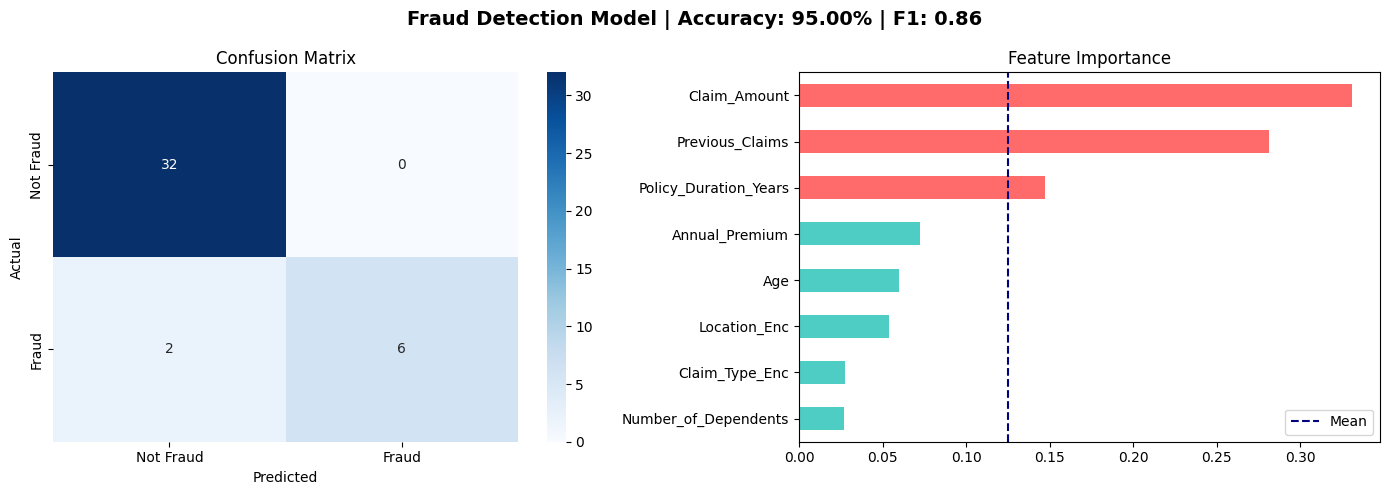

model_accuracy_screenshot.png saved!

fraud_detection_model.pkl saved!
model_metrics.json saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             classification_report, confusion_matrix)

df = pd.read_csv("insurance_claims.csv")
print("Dataset loaded")
print(f"Shape: {df.shape}")
print(f"\nFraud distribution:\n{df['Fraud'].value_counts()}")

le_type     = LabelEncoder()
le_location = LabelEncoder()

df["Claim_Type_Enc"] = le_type.fit_transform(df["Claim_Type"])
df["Location_Enc"]   = le_location.fit_transform(df["Location"])
df["Fraud_Label"]    = (df["Fraud"] == "Yes").astype(int)

joblib.dump(le_type,     "le_type.pkl")
joblib.dump(le_location, "le_location.pkl")

FEATURES = ["Age", "Claim_Amount", "Claim_Type_Enc", "Location_Enc",
            "Previous_Claims", "Policy_Duration_Years",
            "Annual_Premium", "Number_of_Dependents"]

X = df[FEATURES]
y = df["Fraud_Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {len(X_train)} | Test size: {len(X_test)}")

print("\nTraining Random Forest model...")
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)
print("Model trained!")

y_pred = model.predict(X_test)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)

print(f"\n{'='*40}")
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"{'='*40}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Not Fraud", "Fraud"]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Fraud Detection Model | Accuracy: {accuracy*100:.2f}% | F1: {f1:.2f}",
             fontsize=14, fontweight='bold')

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Not Fraud","Fraud"],
            yticklabels=["Not Fraud","Fraud"], ax=axes[0])
axes[0].set_title("Confusion Matrix", fontsize=12)
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
colors = ['#ff6b6b' if v > importances.mean() else '#4ecdc4' for v in importances]
importances.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title("Feature Importance", fontsize=12)
axes[1].axvline(importances.mean(), color='navy', linestyle='--', label='Mean')
axes[1].legend()

plt.tight_layout()
plt.savefig("model_accuracy_screenshot.png", dpi=150, bbox_inches='tight')
plt.show()
print("model_accuracy_screenshot.png saved!")

joblib.dump(model, "fraud_detection_model.pkl")

metrics = {
    "accuracy":  round(accuracy, 4),
    "precision": round(precision, 4),
    "recall":    round(recall, 4),
    "f1_score":  round(f1, 4),
    "train_size": len(X_train),
    "test_size":  len(X_test),
    "features_used": FEATURES,
    "top_feature": importances.idxmax()
}
with open("model_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("\nfraud_detection_model.pkl saved!")
print("model_metrics.json saved!")

# Download deliverables
files.download("model_accuracy_screenshot.png")
files.download("model_metrics.json")

# Model Deployment (API)

In [ ]:

import requests
import json
from google.colab import userdata, files

ML_ENDPOINT = userdata.get("ML_ENDPOINT")
ML_KEY      = userdata.get("ML_KEY")

headers = {
    "Content-Type": "application/json",
    "Authorization": f"Bearer {ML_KEY}"
}

test_cases = {
    "data": [
        {
            "Age": 52, "Claim_Amount": 175000, "Claim_Type": "Vehicle",
            "Location": "Delhi", "Previous_Claims": 6,
            "Policy_Duration_Years": 1, "Annual_Premium": 6000,
            "Number_of_Dependents": 1
        },
        {
            "Age": 34, "Claim_Amount": 15000, "Claim_Type": "Medical",
            "Location": "Mumbai", "Previous_Claims": 0,
            "Policy_Duration_Years": 12, "Annual_Premium": 30000,
            "Number_of_Dependents": 3
        },
        {
            "Age": 41, "Claim_Amount": 80000, "Claim_Type": "Property",
            "Location": "Bangalore", "Previous_Claims": 3,
            "Policy_Duration_Years": 4, "Annual_Premium": 12000,
            "Number_of_Dependents": 2
        }
    ]
}

print("Calling prediction API...")
response = requests.post(ML_ENDPOINT, headers=headers, json=test_cases)

print("Status Code:", response.status_code)

try:
    result = response.json()
except:
    result = {"error": response.text}

print("\n🎯 PREDICTIONS:")
print("=" * 50)

if "predictions" in result:
    for i, pred in enumerate(result["predictions"], 1):
        print(f"Case {i}: Fraud={pred['Fraud_Prediction']} | "
              f"Probability={pred['Fraud_Probability']} | "
              f"Risk={pred['Risk_Level']}")
else:
    print("Error:", result)

# Save output file
deliverable = {
    "api_request": test_cases,
    "api_response": result,
    "status_code": response.status_code,
    "endpoint_used": ML_ENDPOINT
}

with open("api_request_response.json", "w") as f:
    json.dump(deliverable, f, indent=2)

print("\nFile saved!")

files.download("api_request_response.json")

# MLOps + Monitoring

In [ ]:
import requests, json, os

os.environ["ML_ENDPOINT"] = "YOUR_ENDPOINT_URL_FROM_AZURE"
os.environ["ML_KEY"]      = "YOUR_PRIMARY_KEY_FROM_AZURE"

ML_ENDPOINT = os.environ["ML_ENDPOINT"]
ML_KEY      = os.environ["ML_KEY"]

headers = {
    "Content-Type": "application/json",
    "Authorization": f"Bearer {ML_KEY}"
}

test_cases = {
    "data": [
        {
            "Age": 52, "Claim_Amount": 175000, "Claim_Type": "Vehicle",
            "Location": "Delhi", "Previous_Claims": 6,
            "Policy_Duration_Years": 1, "Annual_Premium": 6000,
            "Number_of_Dependents": 1
        },
        {
            "Age": 34, "Claim_Amount": 15000, "Claim_Type": "Medical",
            "Location": "Mumbai", "Previous_Claims": 0,
            "Policy_Duration_Years": 12, "Annual_Premium": 30000,
            "Number_of_Dependents": 3
        },
        {
            "Age": 41, "Claim_Amount": 80000, "Claim_Type": "Property",
            "Location": "Bangalore", "Previous_Claims": 3,
            "Policy_Duration_Years": 4, "Annual_Premium": 12000,
            "Number_of_Dependents": 2
        }
    ]
}

print("Calling prediction API...")
response = requests.post(ML_ENDPOINT, headers=headers, json=test_cases)
print(f"Status Code: {response.status_code}")

result = response.json()
print("\nPREDICTIONS:")
print("=" * 55)
for i, pred in enumerate(result.get("predictions", []), 1):
    print(f"  Case {i}: Fraud={pred['Fraud_Prediction']} | "
          f"Probability={pred['Fraud_Probability']} | "
          f"Risk={pred['Risk_Level']}")

deliverable = {
    "api_request":  test_cases,
    "api_response": result,
    "status_code":  response.status_code,
    "endpoint_used": ML_ENDPOINT
}
with open("api_request_response.json", "w") as f:
    json.dump(deliverable, f, indent=2)

print("\n api_request_response.json saved!")
files.download("api_request_response.json")

In [ ]:

import requests, json, os

os.environ["ML_ENDPOINT"] = "YOUR_ENDPOINT_URL_FROM_AZURE"
os.environ["ML_KEY"]      = "YOUR_PRIMARY_KEY_FROM_AZURE"

ML_ENDPOINT = os.environ["ML_ENDPOINT"]
ML_KEY      = os.environ["ML_KEY"]

headers = {
    "Content-Type": "application/json",
    "Authorization": f"Bearer {ML_KEY}"
}

test_cases = {
    "data": [
        {
            "Age": 52, "Claim_Amount": 175000, "Claim_Type": "Vehicle",
            "Location": "Delhi", "Previous_Claims": 6,
            "Policy_Duration_Years": 1, "Annual_Premium": 6000,
            "Number_of_Dependents": 1
        },
        {
            "Age": 34, "Claim_Amount": 15000, "Claim_Type": "Medical",
            "Location": "Mumbai", "Previous_Claims": 0,
            "Policy_Duration_Years": 12, "Annual_Premium": 30000,
            "Number_of_Dependents": 3
        },
        {
            "Age": 41, "Claim_Amount": 80000, "Claim_Type": "Property",
            "Location": "Bangalore", "Previous_Claims": 3,
            "Policy_Duration_Years": 4, "Annual_Premium": 12000,
            "Number_of_Dependents": 2
        }
    ]
}

print("Calling prediction API...")
response = requests.post(ML_ENDPOINT, headers=headers, json=test_cases)
print(f"Status Code: {response.status_code}")

result = response.json()
print("\nPREDICTIONS:")
print("=" * 55)
for i, pred in enumerate(result.get("predictions", []), 1):
    print(f"  Case {i}: Fraud={pred['Fraud_Prediction']} | "
          f"Probability={pred['Fraud_Probability']} | "
          f"Risk={pred['Risk_Level']}")

deliverable = {
    "api_request":  test_cases,
    "api_response": result,
    "status_code":  response.status_code,
    "endpoint_used": ML_ENDPOINT
}
with open("api_request_response.json", "w") as f:
    json.dump(deliverable, f, indent=2)

print("\napi_request_response.json saved!")
files.download("api_request_response.json")